**How to Use Colab**

1. Go to "File"

2. Click "Save a Copy in Drive" to create your own copy



## 1. Prepare

The first KT case study is inspired by the work of Zambrano, Zhang, & Baker(2024), which analyzed the performance of the Bayesian Knowledge Tracing (BKT) model and carelessness detector on every demographic group in the sample. The primary aim of this case study is to gain some hands-on experience with essential Python packages and functions for Bayesian Knowledge Tracing. This case study and those in the modules that follow are organized around data-intensive workflow processes that are common to Learning Analytics Krumm,, Barbara,& Marie(2018)
:



In this case study, you will learn how to do the data wrangling, fit the model, and analyze the goodness of the model. Zambrano, Zhang, & Baker(2024), utilized the brute-force grid search (BKT-BF, in Java) to fit the BKT model but you will use pyBKT(Python) here. pyBKT is easier to start with but slower in performance. Specifically, this case study addresses the follow topics:

1.  **Prepare**: Before analysis, you'll read a recent paper about BKT, learn about the current trends, and get introduced to the {pandas}, {sklearn}, and {pyBKT} packages for data wrangling and analyzing the BKT model.

2.  **Wrangle**: Then, we will prepare our data for the analysis. This typically involves data cleaning, preprocessing, and transformation to ensure that the data is in a suitable format for modeling.

3.  **Explore**: In this part, you will use descriptive statistics. This step helps you understand the characteristics and patterns within the data before proceeding to modeling.

4.  **Model**: In the model section of the case study, you will learn basic techniques for fitting and evaluating a BKT model. You will also explore a variant of the BKT model and an advanced feature called Roster in the pyBKT package.

5.  **Communication**: This sections will cover how we can share results of your analysis with wider audience.

### 1a. Review the Research

![](images/case-study-paper.png)

[link to the full paper](https://learninganalytics.upenn.edu/ryanbaker/lak24-47-4.pdf)

In this study, Zambrano, Zhang, & Baker(2024) assessed the degree to which algorithmic biases are present in two learning analytics models: knowledge estimates based on Bayesian Knowledge Tracing (BKT) and carelessness detectors. Specifically, this analysis evaluated the model performance across demographic groups, compared performance across intersectional groups of these demographics, and explored models' transferability across unobserved demographics. Performance was similar for students of different races, special needs students, English language learners, economically disadvantaged students, and both male and female students. Results show close to equal performance across these groups.

#### Research Questions

The central goal of this research is to

> investigate the degree to which algorithmic biases are present in two learning analytics models: Bayesian Knowledge Tracing (BKT) and carelessness detectors.

#### Data Collection

The data is from 5,856 students across 12 middle and high schools in a northeastern US city. The students used Carnegie Learning’s MATHia Ritter et al.(2007) software for math instruction during the 2021-2022 academic years. The content includes multi-step questions, guiding students through predetermined content sequences. MATHia's structure closely aligns with the Bayesian Knowledge Tracing (BKT) algorithm.

#### Analysis

The knowledge estimate for specific skills was calculated using BKT. The authors fitted BKT parameters with brute-force grid search. Upper limits of 0.3 and 0.1 for the ’Guess’ and ’Slip’ parameters were adopted respectively to avoid model degeneracy and ensure the parameter values are aligned with conceptual meaning. Demographic characteristics are not taken into calculation directly when building the BKT model. However, sample sizes are not even across demographic groups so the parameters could be more representative of demographics with a larger number of students.

The authors adopted a 4-fold student level cross-validation that was stratified by demographics and evaluated the model performance with AUC ROC. The max difference between AUC for the best and worst predicted group was also calculated.

#### Key Findings

As reported by Zambrano, Zhang, & Baker(2024) in their findings section:

> We found evidence that performance was close to equal across demographic groups, for these models, including intersectional categories, and tests where we held out entire demographic groups during model training (a test of model applicability to entirely new demographic groups), for carelessness.

#### ❓Question

Before we conclude that this model is free of bias, what other tests or data collection might you want to perform?

Type a brief response in the space below:



### 1b. Load Packages

In this case study, you will not replicate the data analysis in Zambrano, Zhang, & Baker(2024). Instead, you will use the data from Baker et al.(2008) to learn how to fit a BKT model. First, you will learn about the essential packages you will be using in this case study.

**Packages**, sometimes called libraries or modules, are shareable collections of Python code that can contain functions, data, and/or documentation and extend the functionality of Python.

#### pandas 📦

One package that you'll be using extensively is [Pandas](https://pandas.pydata.org) (Mckinney,2010). Pandas is a powerful and flexible open-source data analysis and wrangling tool for Python. Python is also used widely by the data science community.

Click the play button on the left of the "code chunk" that follows to load the `pandas` library introduced in LA Workflow labs. If the play button isn't visible, mouse over the code chunk.

In [ ]:
import pandas as pd

#### Numpy📦



NumPy (pronounced /ˈnʌmpaɪ/ NUM-py) is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.

Click the play button on the left of the "code chunk" that follows to load **`numpy`**:

In [ ]:
import numpy as np

#### Pyplot 📦



Pyplot is a module in the {matplotlib) package, a comprehensive library for creating static, animated, and interactive visualizations in Python. **`pyplot`** provides a MATLAB-like interface for making plots and is particularly suited for interactive plotting and simple cases of programmatic plot generation.

Click the play button on the left of the "code chunk" that follows to load **`pyplot`**:

In [ ]:
import matplotlib.pyplot as plt

####scikit learn📦
scikit-learn (formerly scikits.learn and also known as sklearn) is a free and open-source machine learning library for the Python programming language.It features various classification, regression and clustering algorithms including support-vector machines, random forests, gradient boosting, k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.

In [ ]:
from sklearn.model_selection import train_test_split

#### pyBKT 📦

The `pyBKT` package (Badrinath et al., 2021) is a Python implementation of the Bayesian Knowledge Tracing algorithm and variants, estimating student cognitive mastery from problem-solving sequences (Badrinath et al., 2021). PyBKT is not installed by default in Google Colab, so we install it before importing with `!pip install`. Prefixing commands with a `!` runs them in the terminal.

#### **👉 Your Turn** **⤵**

Use the code chunk below to import the pyBKT package:

In [ ]:
!pip install pybkt
from pyBKT.models import Model

## 2. WRANGLE

Data wrangling is the process of converting raw data into a format suitable for analysis. Typically, you will go through data wrangling before data analysis to ensure the high quality of the data and high-quality data leans to better performance. Thus, data wrangling is of great importance in any analysis.

### 2a. Import the dataset

To realize the goals, you'll need to first import the CSV files originally obtained from (Baker et al., 2008) This data set is a subset of the data set used in (Baker et al., 2008). A description of each file is below along with a link to the original file:

1.  [Example CSV dataset](https://learninganalytics.upenn.edu/ryanbaker/EDM2014/AsgnBA3-dataset.zip): This BKT dataset consists of 298 students' performance in 67 skills.

2.  [Dataset description](https://learninganalytics.upenn.edu/ryanbaker/EDM2023/basic-asgn-4-CoreMethods-2023-v1.pdf): This file includes the descriptions of all the variables in this dataset.

First, we download the data from the Laser Institute Github. Note that again the `wget` command is prefixed with a `!`.

In [ ]:
#Download the data here
!wget https://github.com/laser-institute/knowledge-tracing/raw/main/module-1/data/AsgnBA3-dataset.csv

--2024-10-21 16:32:43--  https://github.com/laser-institute/knowledge-tracing/raw/main/module-1/data/AsgnBA3-dataset.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/laser-institute/knowledge-tracing/main/module-1/data/AsgnBA3-dataset.csv [following]
--2024-10-21 16:32:44--  https://raw.githubusercontent.com/laser-institute/knowledge-tracing/main/module-1/data/AsgnBA3-dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10193253 (9.7M) [text/plain]
Saving to: ‘AsgnBA3-dataset.csv.2’

AsgnBA3-dataset.csv 100%[===================>]   9.72M  --.-KB/s    in 0.1s    

2024-10-21 16:32:44 (6

Let's use the `read_csv` function from the `pandas` package to import the `AsgnBA3-dataset.csv`.

In [ ]:
df = pd.read_csv("AsgnBA3-dataset.csv")
df.head()

,ID,Lesson,Student,KC,item,right,firstattempt,time
0,0,Splot,AGUFADE,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-1,1,1,3.29700
1,1,Splot,AGUFADE,VALUING-NUM-FEATURES,META-VALUING-NUM-FEATURES-1,0,1,4.04700
2,2,Splot,AGUFADE,CHOOSE-VAR-TYPE,CHOOSE-VAR-TYPE-NUM-1,1,1,1.59300
3,3,Splot,AGUFADE,VALUING-NUM-FEATURES,META-VALUING-NUM-FEATURES-1,0,0,2.92200
4,4,Splot,AGUFADE,CHOOSE-VAR-TYPE,CHOOSE-VAR-TYPE-NUM-2,1,1,1.59400


`df` here stands for "DataFrame" in the Pandas package. A Pandas DataFrame is a two-dimensional data structure, like a two-dimensional array, or a table with rows and columns. A common convention is to name the DataFrame that you're working on `df`.

**`head()`** on a DataFrame object will display the first 5 rows of the DataFrame.

#### Remove unnecessary rows

In BKT, only the first attempts matter and are included in calculation. Before moving to the next step, use the code chunk below to filter out all the rows in which the firstattempt equals 1.

In [ ]:
df2 = df[df["firstattempt"]==1]

Just as a refresher, in the code above we created a new DataFrame **`df2`** by filtering the original DataFrame **`df`**. In the expression **`df[df["firstattempt"]==1]`**, the brackets serve a specific function in the context of Python's Pandas library:

1.  **Outer Brackets**: These are used to access elements of the DataFrame **`df`**. In Pandas, brackets are used to select columns (when you use a string or list) or rows (when you use slicing or boolean indexing).

2.  **Inner Brackets**: The inner brackets contain the condition **`df["firstattempt"]==1`**. Here, **`df["firstattempt"]`** selects the column named "firstattempt" from the DataFrame, and selects only the rows where the value of the column **`"firstattempt"`** is equal to 1.

Essentially, **`df2`** will contain all the rows from **`df`** where the first attempt at a the test question is marked by a 1, indicating that it was indeed the student's first attempt.

#### **👉 Your Turn** **⤵**

Now filter out all the rows that represent the "CHOOSE-X-AXIS-QUANTITATIVE" skill and assign the result to the variable `df3` .

In [ ]:
df3 = df2[df2["KC"]=="CHOOSE-X-AXIS-QUANTITATIVE"]


#### Mapping the column names

The accepted input formats in pyBKT are Pandas DataFrames and data files of type CSV (comma separated) or TSV (tab separated). pyBKT will automatically infer which delimiter to use in the case that it is passed a data file. Since column names mapping meaning to each field in the data (i.e. skill name, correct/incorrect) varies per data source, you may need to specify a mapping from your data file's column names to pyBKT's expected column names.

Thus, you will need to create a column name mapping before training the model.

In [ ]:
defaults = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student'}

This is a dictionary. Dictionaries are used to store data values in key: value pairs. Dictionaries are written with curly brackets. Here’s what each part of the code is doing:

-   **`defaults = {...}`**: This initializes **`defaults`** as a Python dictionary. Dictionaries in Python are collections of key-value pairs, which are used to store data values like a map.

-   **Key-Value Pairs**: Inside the dictionary, there are several key-value pairs defined:

    -   **`'order_id': 'ID'`** maps the key **`'order_id'`** to the value **`'ID'`**.

    -   **`'skill_name': 'KC'`** maps the key **`'skill_name'`** to the value **`'KC'`**.

    -   **`'correct': 'right'`** maps the key **`'correct'`** to the value **`'right'`**.

    -   **`'user_id': 'Student'`** maps the key **`'user_id'`** to the value **`'Student'`**.

The column names you need to specify are order_id, skill_name, correct, and user_id. You may refer to the document in 2a about the descriptions of all the variables.

## 3. EXPLORE

Before we begin learning about how to fit a basic BKT model, we'll use several methods to explore our data.

### 3a. Descriptive statistics

### Head()

In [ ]:
df3.head()

,ID,Lesson,Student,KC,item,right,firstattempt,time
21,21,Splot,AGUFADE,CHOOSE-X-AXIS-QUANTITATIVE,CHOOSE-X-AXIS-QUANTITATIVE-1,0,1,3.59400
263,263,Splot,AOADMAC,CHOOSE-X-AXIS-QUANTITATIVE,CHOOSE-X-AXIS-QUANTITATIVE-1,0,1,9.06200
391,396,Splot,AOADMAC,CHOOSE-X-AXIS-QUANTITATIVE,CHOOSE-X-AXIS-QUANTITATIVE-2,1,1,15.65600
483,493,Splot,AOADMAC,CHOOSE-X-AXIS-QUANTITATIVE,CHOOSE-X-AXIS-QUANTITATIVE-3,1,1,5.68700
559,569,Splot,AOADMAC,CHOOSE-X-AXIS-QUANTITATIVE,CHOOSE-X-AXIS-QUANTITATIVE-4,1,1,9.78200


**`head()`** is a function provided by pandas for DataFrames. When you call **`head()`** on a DataFrame, it shows you the first few rows of your data. By default, it displays the first 5 rows, but you can specify a different number if you want.

#### Describe()

In [ ]:
df3.describe()

,ID,right,firstattempt,time
count,832.00000,832.00000,832.00000,832.00000
mean,"37,436.28005",0.68269,1.00000,20.49003
std,"20,547.14893",0.46571,0.00000,28.66324
min,21.00000,0.00000,1.00000,0.00000
25%,"20,365.50000",0.00000,1.00000,6.08975
50%,"38,358.00000",1.00000,1.00000,13.77500
75%,"54,615.50000",1.00000,1.00000,24.23625
max,"71,200.00000",1.00000,1.00000,381.03800


1.  **describe()**: **`describe()`** is a function provided by pandas for DataFrames. When you call **`describe()`** on a DataFrame like **`df3`**, it gives you some basic statistics about the data in each column. These statistics include things like count, mean, standard deviation, minimum, maximum, and various percentiles.

#### Histogram of Time Column

We could also create a Histogram of the time column using the code chunk below:

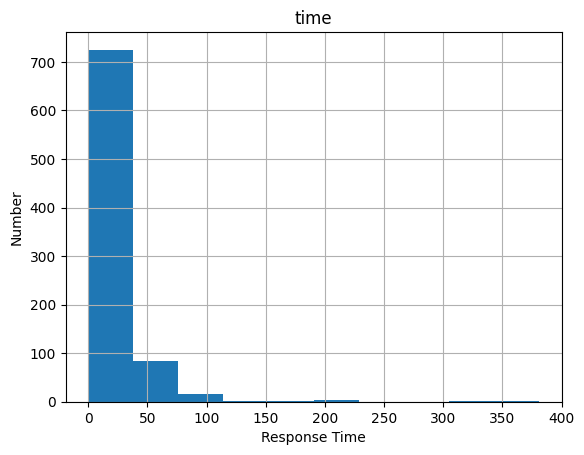

In [ ]:
df3.hist(column='time', bins= 10)
plt.xlabel('Response Time')
plt.ylabel('Number')
plt.show()

1.  **`import matplotlib.pyplot as plt`**: This line (back in step 1b, above) imports the Matplotlib library, specifically the submodule **`pyplot`**, and assigns it the alias **`plt`**. This makes it easier to refer to Matplotlib functions later in the code.

2.  **`hist_time = df3.hist(column='time')`**: This line creates a histogram of a specific column named 'time' from the DataFrame called **`df3`**. In this line:

    -   **`df3`** is the DataFrame we have cleaned so far.

    -   **`hist()`** is a function provided by pandas to create histograms. You're specifying the column you want to create the histogram for by passing the argument **`column='time'`**.

    -   The result of **`hist()`** is stored in the variable **`hist_time`**, although it's not necessary for the code to function. This variable could be used later if you want to modify or analyze the histogram further.

3.  **`plt.show()`**: This line displays the histogram that was created. After you've created a plot using Matplotlib, you typically use **`plt.show()`** to actually visualize it. Without this line, the histogram would be created but not shown on the screen.

If you would like to look into a specific range, you could add the parameter `range=` . For example:

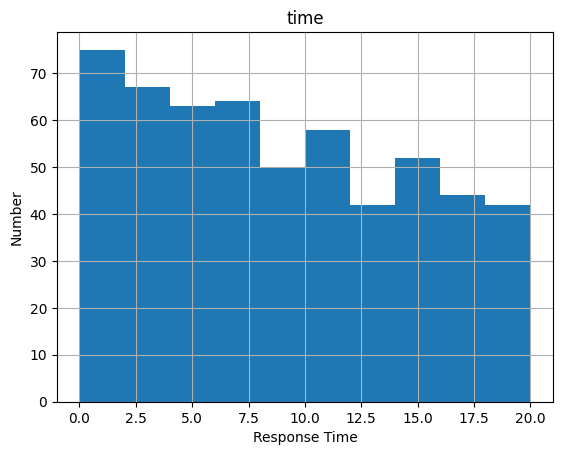

In [ ]:
df3.hist(column='time', bins= 10, range=[0,20])
plt.xlabel('Response Time')
plt.ylabel('Number')
plt.show()

A parameter refers to a variable that is used in a function or method to receive a value when the function is called. Here's a simple example in Python:

In [ ]:
def greet(name):
    print("Hello, " + name + "!")

greet("Alice")

Hello, Alice!


In this example, **`name`** is a parameter of the **`greet`** function. When we call the **`greet`** function and pass in the argument "Alice", the value of "Alice" is assigned to the **`name`** parameter within the function.

Parameters allow functions to be more flexible and reusable because they enable the function to work with different data each time it is called.

## 4. MODEL

In this section we'll learn to fit a basic BKT model, but what exactly does is mean to "fit" a model?

This is an example of model fitting:

In this example, linear regression is used to fit the model and this is one of the simplest techniques. You are fitting the model (the line) to a dataset (the dots). The model will be on the form y = a x + b, and you’re trying to find the optimal values of a and b. You draw a line that best fits the existing data points on average. Once you’ve fitted the model, you can use it to predict outcomes (y-axis) based on inputs (x-axis).

### 4a. Fit the model

pyBKT makes fitting the model very easy. It only takes 2 lines:

In [ ]:
model = Model(seed=42)
model.fit(data = df3, defaults = defaults)
print(model.params())

                                             value
skill                      param   class          
CHOOSE-X-AXIS-QUANTITATIVE prior   default 0.50016
                           learns  default 0.44768
                           guesses default 0.21683
                           slips   default 0.15422
                           forgets default 0.00000


First, use the `Model` function of the pyBKT package to create a BKT model.

The `seed` parameter is used to initialize the random number generator. The random number generator needs a number to start with (a seed value), to be able to generate a random number.

Then, use the `fit` method and input `df3` and `defaults`, the dataset you have cleaned so far, and the column name mapping.

Let's run the code chunk below to see what are the best parameters.

In [ ]:
print(model.params())

                                             value
skill                      param   class          
CHOOSE-X-AXIS-QUANTITATIVE prior   default 0.50016
                           learns  default 0.44768
                           guesses default 0.21683
                           slips   default 0.15422
                           forgets default 0.00000


#### RMSE and AUC

pyBKT provides various ways to evaluate your BKT model, such as RMSE, and AUC.

In [ ]:
training_rmse = model.evaluate(data = df3)
training_auc = model.evaluate(data= df3, metric = 'auc')

print("Training RMSE: %f" % training_rmse)
print("Training AUC: %f" % training_auc)

Training RMSE: 0.446825
Training AUC: 0.653699


The Root Mean Squared Error (RMSE) is one of the two main performance indicators for a regression model. It measures the average difference between values predicted by a model and the actual values. To put it simply, the lower, the better.

AUC ROC is the area under the ROC curve. Baker et al.(2024) point out that the ROC curve shows the trade-off between the sensitivity and specificity of the model. When expanded to the entire curve, it shows this trade-off across all possible thresholds.

#### Create additional metrics

You can even create metrics, such as the sum of squared residuals (SSR), used by BKT-BF (Baker et al., 2010)

In [ ]:
def SSR(true_vals, pred_vals):
  return np.sum(np.square(true_vals - pred_vals))
training_SSR = model.evaluate(data= df3, metric = SSR)
print("Training SSR: %f" % training_SSR)

Training SSR: 166.111049


The sum of squared residuals (SSR) **measures the level of variance in the error term, or residuals, of a regression model**. The smaller the residual sum of squares, the better your model fits your data; the greater the residual sum of squares, the poorer your model fits your data.

#### **👉 Your Turn** **⤵**

Split the data into the training set and the testing set by 80%/20% and fit your BKT model on a skill. This skill should not be the same as the one above or the skill in the ASSISTments activity. Then, evaluate the RMSE and AUC on the test set.

In [ ]:
import random
random.seed(42)

def student_level_split(data, student_column, test_fraction):
  """Creates train/test splits from the given dataframe at student level (all rows from one student should be placed in the same split).
  data: The dataframe to work on.
  student_column: The column in the dataframe with student IDs.
  test_fraction: A value between 0 and 1 representing the proportion of the data that should be in the test split.

  Returns two dataframes, the training data and the testing data in that order.
  Adds a column showing the random values that were used to make the splits."""
  students = data[student_column].unique()
  split_dictionary = {} #Create a dictionary to store a random split value for each student.
  for student in students:
    split_dictionary[student] = random.random() #Assign a random value to each student.
  data['split_criterion'] = data[student_column].map(split_dictionary) #Add the random split values to the dataframe.
  return data[data['split_criterion'] > test_fraction], data[data['split_criterion'] <= test_fraction] #Split the data into training and testing using the split values.

train_df, test_df = student_level_split(df2, 'Student', 0.2)
print(train_df, test_df)

            ID                 Lesson  Student                    KC  \
0            0                  Splot  AGUFADE  VALUING-CAT-FEATURES   
1            1                  Splot  AGUFADE  VALUING-NUM-FEATURES   
2            2                  Splot  AGUFADE       CHOOSE-VAR-TYPE   
4            4                  Splot  AGUFADE       CHOOSE-VAR-TYPE   
6            6                  Splot  AGUFADE  VALUING-NUM-FEATURES   
...        ...                    ...      ...                   ...   
124091  128595  MidZSchoolZProbabilit  QIDIKGB       ENTER-UNREDUCED   
124092  128596  MidZSchoolZProbabilit  QIDIKGB       ENTER-UNREDUCED   
124094  128598  MidZSchoolZProbabilit  QIDIKGB             ENTER-GCD   
124096  128600  MidZSchoolZProbabilit  QIDIKGB           GREATEST-CF   
124097  128601  MidZSchoolZProbabilit  QIDIKGB             ENTER-GCD   

                               item  right  firstattempt     time  \
0       META-VALUING-CAT-FEATURES-1      1             1  3.29700 

In [ ]:
#split the dataset by 80%/20%
train, test = train_test_split(df2, test_size= 0.2)
single_skill_train = train[train['KC']=="CHOOSE-X-AXIS-QUANTITATIVE"]
single_skill_test = test[test['KC']=="CHOOSE-X-AXIS-QUANTITATIVE"]
#df3 = df2[df2["KC"]=="CHOOSE-X-AXIS-QUANTITATIVE"]
#Fitting
model_split = Model(seed=42)
model_split.fit(data=train, defaults=defaults)

model_singleskill = Model(seed = 42)
model_singleskill.fit(data=single_skill_train, defaults=defaults)

#Testing
testing_rmse = model_singleskill.evaluate(data = single_skill_test)
testing_auc = model_singleskill.evaluate(data= single_skill_test, metric = 'auc')
print(model_singleskill.params())
print("Training RMSE: %f" % training_rmse)
print("Training AUC: %f" % training_auc)

                                             value
skill                      param   class          
CHOOSE-X-AXIS-QUANTITATIVE prior   default 0.38719
                           learns  default 0.29106
                           guesses default 0.39453
                           slips   default 0.06934
                           forgets default 0.00000
Training RMSE: 0.446825
Training AUC: 0.653699


### 4b. Conditionalizing in BKT

#### Conditionalize guess, slip, and learn on other factors

You can also conditionalize guess, slip, or learn on other factors in the BKT model -- something used for practical purposes (Beck et al., 2008) and (Baker, Sujith & Eyad, 2018). You need to provide guess/slip/learn classes to use in fitting the model. Let's say you are going to fit each item's priors, learn rate, guess, and slip model with the data (Pardos & Heffernan, 2011). You will need to first specify which column is the class.

Use the code chunk below to test this variant:

In [ ]:
defaults_multi = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student', 'multigs': 'item', 'multilearn':'item'}
model_multi = Model(seed=42, num_fits = 1)

model_multi.fit(data= df3, multilearn = True, multigs= True, defaults = defaults_multi)
print(model_multi.params())

                                                                   value
skill                      param   class                                
CHOOSE-X-AXIS-QUANTITATIVE prior   default                       0.80665
                           learns  CHOOSE-X-AXIS-QUANTITATIVE-1  0.71828
                                   CHOOSE-X-AXIS-QUANTITATIVE-10 0.45880
                                   CHOOSE-X-AXIS-QUANTITATIVE-11 1.00000
                                   CHOOSE-X-AXIS-QUANTITATIVE-2  0.59323
                                   CHOOSE-X-AXIS-QUANTITATIVE-3  0.58896
                                   CHOOSE-X-AXIS-QUANTITATIVE-4  0.58888
                                   CHOOSE-X-AXIS-QUANTITATIVE-5  0.92769
                                   CHOOSE-X-AXIS-QUANTITATIVE-6  0.45929
                                   CHOOSE-X-AXIS-QUANTITATIVE-7  0.37564
                                   CHOOSE-X-AXIS-QUANTITATIVE-8  0.46272
                                   CHOOSE-X-AXIS-QU

As you can see from the output, each item now has the guess, slip, and learn rate. You can conditionalize on lots of factors, depending on the dataset you collected.

#### **👉 Your Turn** **⤵**

### ❓Challenge: Conditionalize slip on response time

For example, perhaps you want to modify to conditionalize slip on whether the time taken was under 5 seconds. Thus, you will have two sets of the 4 classical parameters: one set is for those actions that took more than 5 seconds and the other set is for those actions that take less than 5 seconds. Please notice that this is not exactly great practice. A more sophisticated approach is seen in (Baker, Corbett, & Aleven, 2008). but it’s feasible with the data set you have.

The current dataset only has response time. You will need to create another binary column for this challenge. Please build this model on the "VALUING-CAT-FEATURES" skill.

#### Build a Column on whether the students took more than 5 seconds

In [ ]:
df4=df2[df2['KC']=='VALUING-CAT-FEATURES']
df4["FiveSecs"] = df['time']>5

In [ ]:
df4

,ID,Lesson,Student,KC,item,right,firstattempt,time,split_criterion,FiveSecs
0,0,Splot,AGUFADE,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-1,1,1,3.29700,0.63943,False
7,7,Splot,AGUFADE,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-2,0,1,3.20300,0.63943,False
250,250,Splot,AOADMAC,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-1,1,1,8.00000,0.02501,True
253,253,Splot,AOADMAC,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-2,0,1,2.84300,0.02501,False
378,383,Splot,AOADMAC,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-3,0,1,1.78100,0.02501,False
...,...,...,...,...,...,...,...,...,...,...
69932,71275,Splot,KBRIZPT,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-5,1,1,2.14000,0.59452,False
69990,71333,Splot,KBRIZPT,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-6,1,1,8.02000,0.59452,True
69994,71337,Splot,KBRIZPT,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-7,1,1,1.65000,0.59452,False
70072,71415,Splot,KBRIZPT,VALUING-CAT-FEATURES,META-VALUING-CAT-FEATURES-8,1,1,56.69000,0.59452,True


#### Build your 5 seconds model

In [ ]:

defaults = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student', 'multigs': 'FiveSecs'}
model_5sec = Model(seed = 42, num_fits = 1)
model_5sec.fit(data= df4, multigs = True,defaults = defaults)
print(model_5sec.params())

                                       value
skill                param   class          
VALUING-CAT-FEATURES prior   default 0.95405
                     learns  default 0.15957
                     guesses False   0.17229
                             True    0.58077
                     slips   False   0.36455
                             True    0.15007
                     forgets default 0.00000


### 4c. Cross Validation in BKT

pyBKT also allows you to easily use cross-validation.

Cross-validation is a technique to evaluate the performance of a model on unseen data. The picture below shows how the 5-fold cross-validation works.

Cross-validation is offered as function similar to a combination of fit and evaluate that accepts a particular number of folds, a seed, and a metric(either one of the 3 provided 'rmse', 'auc' or 'accuracy' -- a custom Python function)

In [ ]:
model2 = Model(seed = 42, num_fits=1)
cross_vali = model2.crossvalidate(data = df3, folds = 10, defaults = defaults, metric = 'auc')
print(cross_vali)

                               auc
skill                             
CHOOSE-X-AXIS-QUANTITATIVE 0.62969


#### **👉 Your Turn** **⤵**

### ❓Challenge: Cross-validation on your response time model

Please use the code chunk below to conduct 10-fold cross-validation on your response time model and answer the following question:

Is the model better than classic BKT when conditionalizing slip on response time? Why?

In [ ]:
defaults = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student', 'multigs': 'FiveSecs'}
cross_validation = model_5sec.crossvalidate(data = df4, folds = 10, defaults = defaults, metric = 'auc', multigs= True)
print(cross_validation)

                         auc
skill                       
VALUING-CAT-FEATURES 0.66780


### 4c. Other advanced features in pyBKT

pyBKT also offers some other advanced features, such as Roster and Parameter Fixing.

### 4a. Roster

Roster is used to simulate the learning environment for a group of students learning any combination of individual skills.

You need to first create a backend pyBKT model and fit it on the dataset.

In [ ]:
defaults_roster = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student'}
model_roster = Model()
model_roster.fit(data = df2, defaults = defaults_roster )

Then you can use the `Roster` to create a roster with two students and one skill.

In [ ]:
from pyBKT.models import *
roster = Roster(students = ['Jack', 'Rachel'], skills = "VALUING-NUM-FEATURES", model = model_roster)

You can update Rachel's status by adding one or more responses to a particular skill. In this case, Rachel correctly answered one question. Then check Rachel's updated mastery state and probability.

In [ ]:
rachel_new_state = roster.update_state('VALUING-NUM-FEATURES', 'Rachel', 1)
print("Rachel's mastery:", roster.get_state_type('VALUING-NUM-FEATURES', 'Rachel'))
print("Rachel's probability of mastery:", roster.get_mastery_prob('VALUING-NUM-FEATURES', 'Rachel'))

Rachel's mastery: StateType.UNMASTERED
Rachel's probability of mastery: 0.5826197465475196


#### **👉 Your Turn** **⤵**

Create a new roster on the model you fitted in section 2. If you add 3 consecutive correct answers to Rachel and 3 consecutive incorrect answers to Jack, will they be assessed as having mastered the skill or not? Use the code chunk below:

In [ ]:
#Add 3 consecutive correct answers to Rachel and 3 consecutive incorrect answers to Jack,
roster = Roster(students = ['Jack', 'Rachel'], skills = "VALUING-NUM-FEATURES", model = model_roster)
roster.update_state('VALUING-NUM-FEATURES', 'Rachel', np.ones(3))
roster.update_state('VALUING-NUM-FEATURES', 'Jack', np.zeros(3))

print("Jack's probability of mastery:", roster.get_mastery_prob('VALUING-NUM-FEATURES', 'Jack'))
print("Rachel's probability of mastery:", roster.get_mastery_prob('VALUING-NUM-FEATURES', 'Rachel'))

Jack's probability of mastery: 0.11695510900143195
Rachel's probability of mastery: 0.7259987600284905


### 4b. Parameter Fixing

Another advanced feature supported by pyBKT is parameter fixing, where you can fix one or more parameters and train the model conditioned on those fixed parameters. For example, you could fix the slip rate to 0.2.

In [ ]:
model_fixedparam = Model()
defaults = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student'}
model_fixedparam.coef_ = {'CHOOSE-X-AXIS-QUANTITATIVE': {'slips': np.array([0.2])}}
model_fixedparam.fit(data = df3, fixed=True, defaults = defaults)
model_fixedparam.params()

value
skill                      param   class          
CHOOSE-X-AXIS-QUANTITATIVE prior   default 0.66381
                           learns  default 0.49649
                           guesses default 0.06015
                           slips   default 0.20000
                           forgets default 0.00000

#### **👉 Your Turn** **⤵**

Fix the slip rate to 0.3 and the guess rate to 0.2 when fitting your model, Does the model perform better or worse?

In [ ]:
model_fixedparam = Model(seed=42)
defaults = {'order_id': 'ID', 'skill_name': 'KC', 'correct': 'right', 'user_id': 'Student'}
model_fixedparam.coef_ = {'CHOOSE-X-AXIS-QUANTITATIVE': {'slips': np.array([0.3]), 'guesses': np.array([0.2])}}
model_fixedparam.fit(data = df3, fixed=True, defaults = defaults)
model_fixedparam.params()

value
skill                      param   class          
CHOOSE-X-AXIS-QUANTITATIVE prior   default 0.64287
                           learns  default 0.61806
                           guesses default 0.20000
                           slips   default 0.30000
                           forgets default 0.00000